In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ta.momentum import RSIIndicator
from ta.trend import MACD

In [4]:
df = pd.read_csv("../data/AAPL.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [6]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

df = df.dropna()

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [7]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

In [8]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

In [9]:
df['RSI'] = RSIIndicator(df['Close'], window=14).rsi()

In [10]:
macd = MACD(df['Close'])

df['MACD'] = macd.macd()
df['Signal'] = macd.macd_signal()
df['Histogram'] = macd.macd_diff()

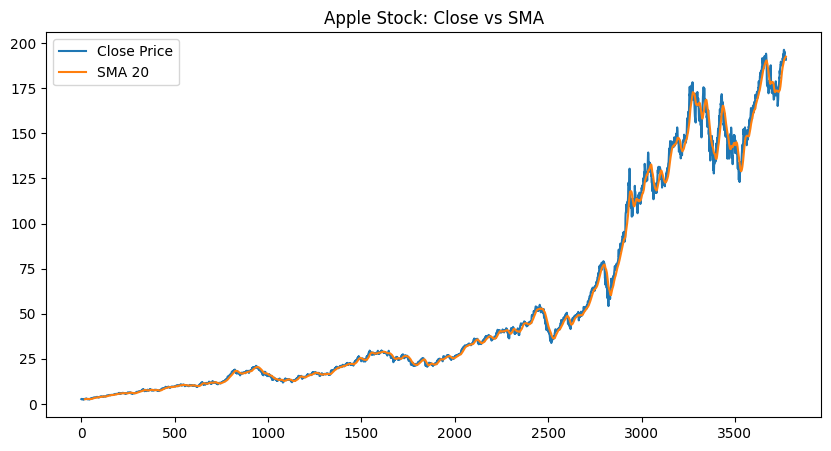

In [11]:
plt.figure(figsize=(10,5))

plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')

plt.title("Apple Stock: Close vs SMA")
plt.legend()
plt.show()

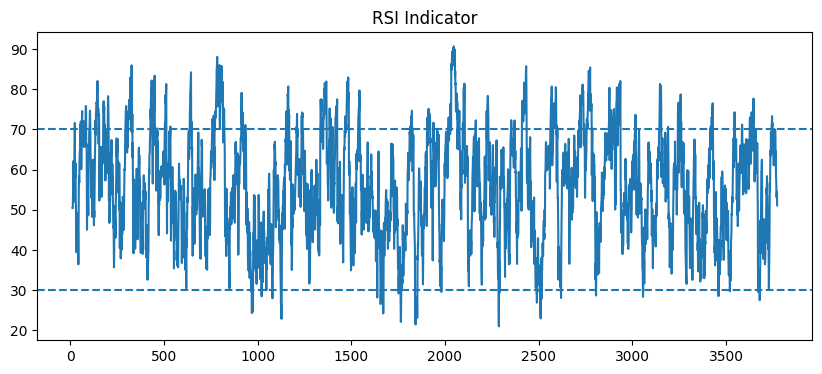

In [12]:
plt.figure(figsize=(10,4))

plt.plot(df['RSI'])
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title("RSI Indicator")
plt.show()

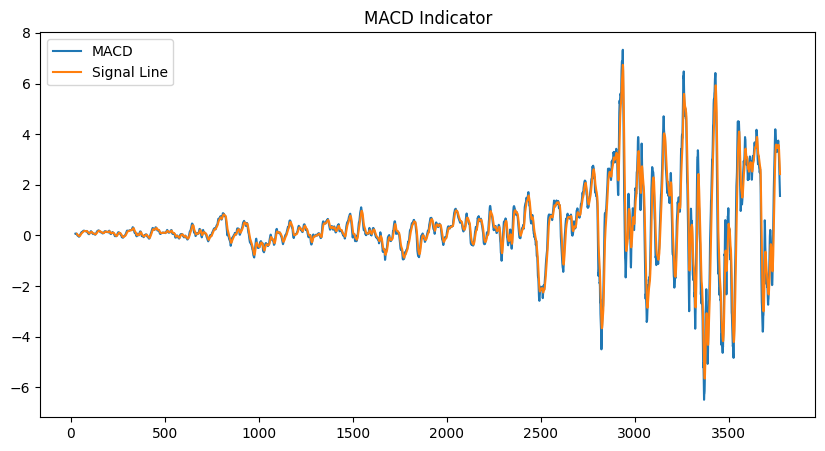

In [13]:
plt.figure(figsize=(10,5))

plt.plot(df['MACD'], label='MACD')
plt.plot(df['Signal'], label='Signal Line')

plt.title("MACD Indicator")
plt.legend()
plt.show()